# Food Delivery Data Analysis 

 

### Context

The growth of online food delivery platforms has transformed how people access restaurant services in large metropolitan cities. Busy professionals, students, and families increasingly depend on these platforms to order meals conveniently through mobile applications.

FoodHub is an online food aggregation platform that connects customers with multiple restaurants through a single mobile application. Customers can browse restaurant menus, place orders, and receive their meals through delivery personnel assigned by the platform.

Understanding customer ordering behavior, restaurant performance, and delivery efficiency is essential for improving service quality. By analyzing order data collected through the platform, valuable insights can be generated to support operational decisions and improve the overall customer experience.

### Objective
**The company wants to analyze this data to better understand:**
**As a Data Scientist working with this food delivery company, my task is to analyze the order data and generate insights that will help the company:**

* Customer ordering behavior
* Demand patterns for different restaurants
* Popular cuisines among customers
* Delivery performance and service efficiency
* Improve delivery efficiency
* Identify high-demand restaurants and cuisines
* Enhance customer satisfaction
* Support business growth and decision making

### Project Goal
By analyzing this dataset, the goal is to generate actionable insights that will help the food delivery platform to:
Identify the most popular restaurants and cuisines
Understand customer ordering patterns
Evaluate restaurant preparation performance
Measure delivery efficiency
Improve overall customer experience



### Data Description
The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary
* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* taurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the * * * timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information




### Importing the necessary Libraries for the project

In [2]:
# !pip install numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as style
%matplotlib inline

import seaborn as sns

### Loading or importing  the  dataset for the project

In [4]:
df = pd.read_csv("foodhub_order.csv")

### Doing the sanity check of the Dataset

In [119]:
#THIS IS TO CHECK FOR THE FIRST FIVE ROWS AND THE COLUMNS IN OUR DATASET
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [120]:
#CHECKING FOR THE SHAPE OF THE DATASET
df.shape

(1898, 9)

In [121]:
#CHECKIGNG FOR THE STATISTICAL SUMMERY OF THE DATASET
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [122]:

#CHECKING FOR DATA TYEPES OF THE DATA FRAME COLUMNS
df.dtypes

order_id                   int64
customer_id                int64
restaurant_name           object
cuisine_type              object
cost_of_the_order        float64
day_of_the_week           object
rating                    object
food_preparation_time      int64
delivery_time              int64
dtype: object

In [123]:
#CHECKING FOR THE INFORMATION ABOUT THE DATASET 
df.info;

In [124]:
df.describe(include = 'object')

,restaurant_name,cuisine_type,day_of_the_week,rating
count,1898,1898,1898,1898
unique,178,14,2,4
top,Shake Shack,American,Weekend,Not given
freq,219,584,1351,736


In [125]:
#CHECKING FOR WHETHER SOME OF THE COLUMNS IS HAVING A MISSING VALUES
df.isna().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

In [126]:
#CHECKING WHETHER A COLUMN IS HAVEING DUPLICATES
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1893    False
1894    False
1895    False
1896    False
1897    False
Length: 1898, dtype: bool

**Looking for number of orders which are not related**

In [127]:
# df["rating"].isin(["Not given"]).sum()

#this code is best
df["rating"].value_counts().head()

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

This show that 736 rating where not given

# Exploretory Data Analysis
#### Univarite Analysis

##### After the Sanity checks (food_perparation_time, delivery_time, cost_of_the _order, rating are all Numberical variables). (cuisine_type, day_of_the_week are all  Categorical variables). I want  to start the exploretory analysis with the categorical variables.

In [128]:
df.columns

Index(['order_id', 'customer_id', 'restaurant_name', 'cuisine_type',
       'cost_of_the_order', 'day_of_the_week', 'rating',
       'food_preparation_time', 'delivery_time'],
      dtype='object')

In [129]:
df["cuisine_type"].value_counts()

cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64

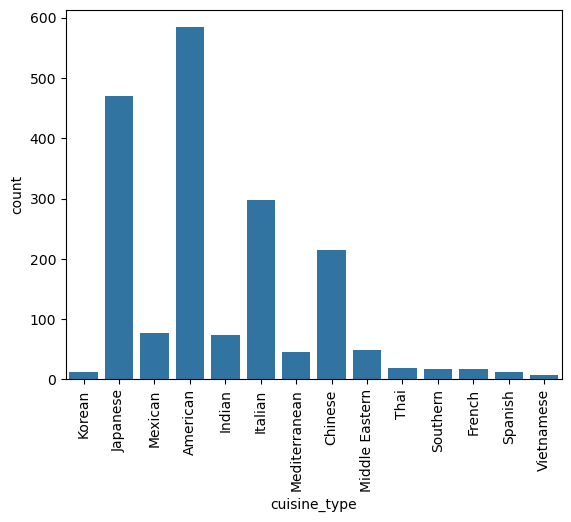

In [130]:
sns.countplot(data = df, x='cuisine_type')
plt.xticks(rotation = 90)
plt.show;

**REPORTING FROM OBSERVATION** According to the observation the most frequently ordered cuisine is Amrican followed by Japanes and Italian. This shows clear that there are higher demand of these food types. And it again indicates that there must be less attention payed to the Vetnamese, Spanish and Korean food types because they are very low demand.

In [131]:
df["day_of_the_week"].value_counts()


day_of_the_week
Weekend    1351
Weekday     547
Name: count, dtype: int64

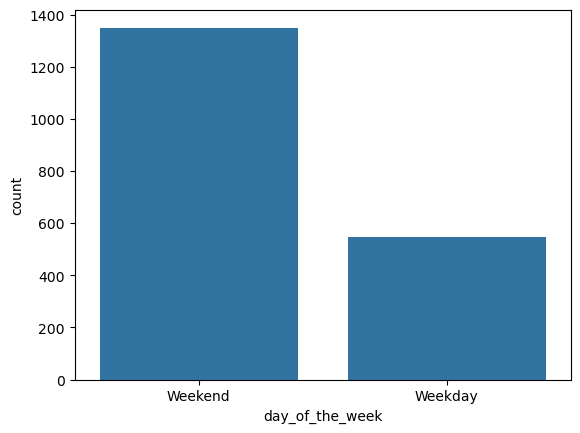

In [132]:
sns.countplot(data = df, x= "day_of_the_week")
plt.show;

**REPORTING FROM OBSERVATION** According to the observation, it indicaate clearly that purching on weekend is very high as compare to weekday.

# Numerical Univariate analysis of the dataset

In [133]:
 df.columns

Index(['order_id', 'customer_id', 'restaurant_name', 'cuisine_type',
       'cost_of_the_order', 'day_of_the_week', 'rating',
       'food_preparation_time', 'delivery_time'],
      dtype='object')

In [134]:
df["cost_of_the_order"].describe()

count    1898.000000
mean       16.498851
std         7.483812
min         4.470000
25%        12.080000
50%        14.140000
75%        22.297500
max        35.410000
Name: cost_of_the_order, dtype: float64

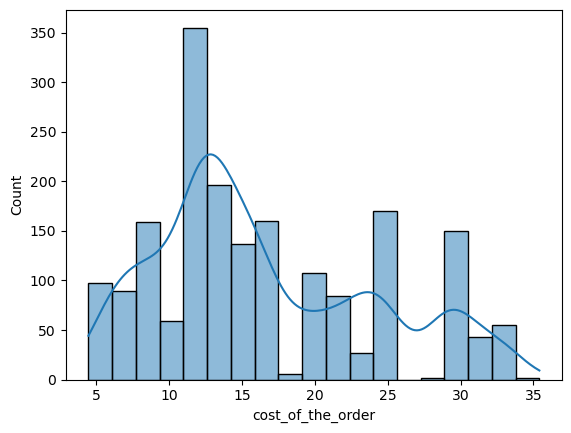

In [135]:
#displaying cost_of_the_order
sns.histplot(data = df['cost_of_the_order'], kde=True)
plt.show;

#### Using box plot for the cost_of_the_order variable in order to identify outliers


In [136]:
df['cost_of_the_order'].describe()

count    1898.000000
mean       16.498851
std         7.483812
min         4.470000
25%        12.080000
50%        14.140000
75%        22.297500
max        35.410000
Name: cost_of_the_order, dtype: float64

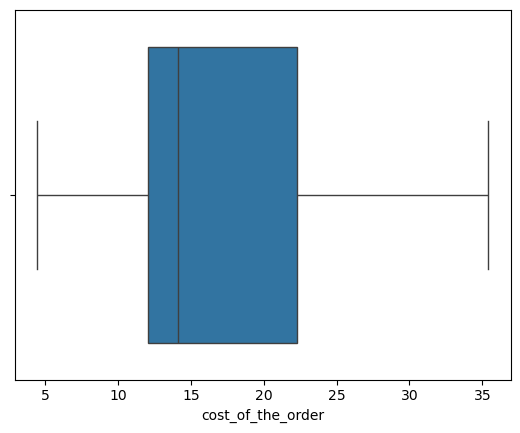

In [137]:
sns.boxplot(data = df, x='cost_of_the_order')
plt.show;

### The above observation shows the avarage order cost $16. And the distribution is also slightly skewed  right with a few high-cost outliers.

## Univariate Analysis for Rating


In [138]:
df["rating"].isna().sum()

np.int64(0)

In [139]:
# df[["rating" , "Not given"]].sum()

In [140]:
df["rating"].describe()

count          1898
unique            4
top       Not given
freq            736
Name: rating, dtype: object

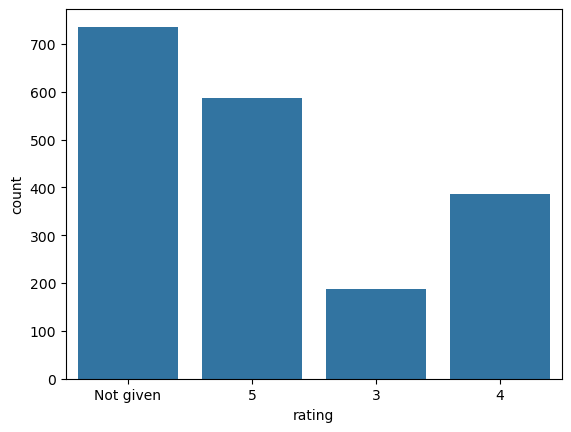

In [141]:
#Plotting the rating variable with count plot
sns.countplot(data = df, x='rating')
plt.show;

#### From the observation majority of the votes fall between 5 and 4 depicting highly customer satisfaction. 

## Univarite Analysis for food perparation time


In [142]:
df["food_preparation_time"].describe()

count    1898.000000
mean       27.371970
std         4.632481
min        20.000000
25%        23.000000
50%        27.000000
75%        31.000000
max        35.000000
Name: food_preparation_time, dtype: float64

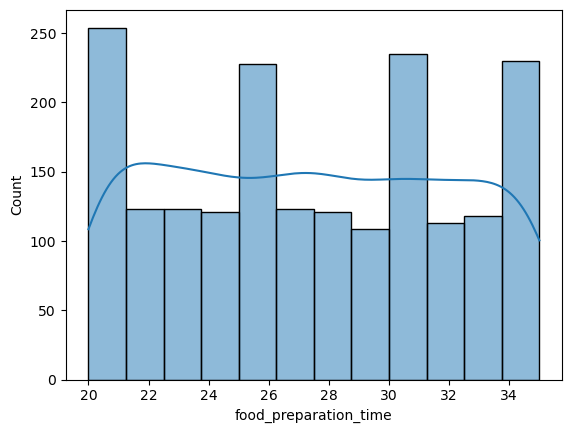

In [143]:
#Plotting food perparation time  with histogram
sns.histplot(data = df, x='food_preparation_time', kde=True)
plt.show;

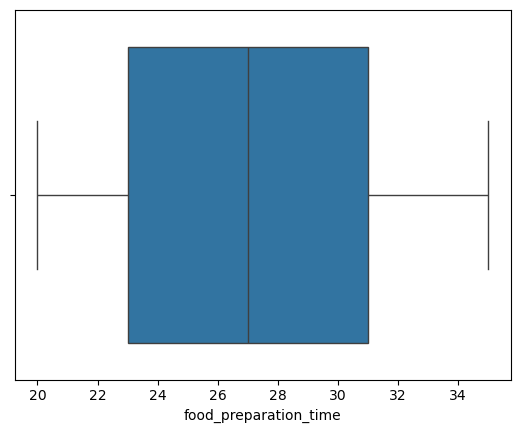

In [144]:
#Using box plot for clarification
sns.boxplot(data=df, x="food_preparation_time")
plt.show();

#### The average food preparation time is approximatly 27 minutes,despite a few reatuarants taking significantly longer

## Univarite Analysis for delivery time

In [145]:
df["delivery_time"].describe()

count    1898.000000
mean       24.161749
std         4.972637
min        15.000000
25%        20.000000
50%        25.000000
75%        28.000000
max        33.000000
Name: delivery_time, dtype: float64

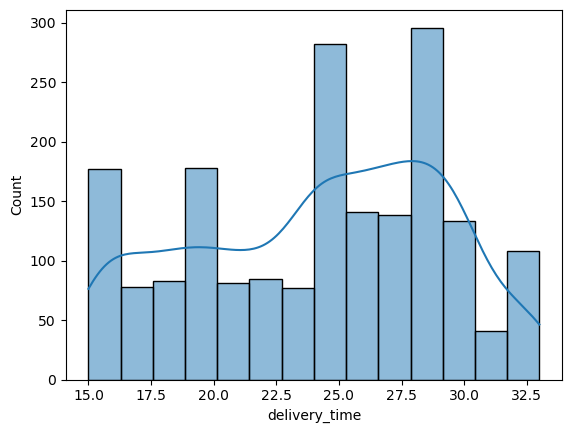

In [146]:
#Using histogram to plot the delivery time
sns.histplot(data =df, x="delivery_time", kde=True)
plt.show;

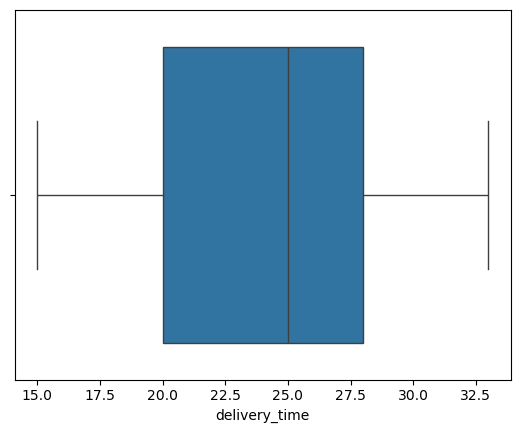

In [147]:
# Using box plot for the delivery time variable
sns.boxplot(data=df, x="delivery_time")
plt.show();

#### The delivery time range from 15 to 33 minutes with an average of 24 minutes.

## After the exploratory and the findings there are extra analysis in questions

**Getting to know the the top 5 restaurants in terms of number they recieved**

In [148]:
df.head(1)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20


In [149]:
top5_restaurant_in_order= df["restaurant_name"].value_counts().head(5)
top5_restaurant_in_order

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

In [150]:
to5_data=pd.DataFrame(top5_restaurant_in_order)

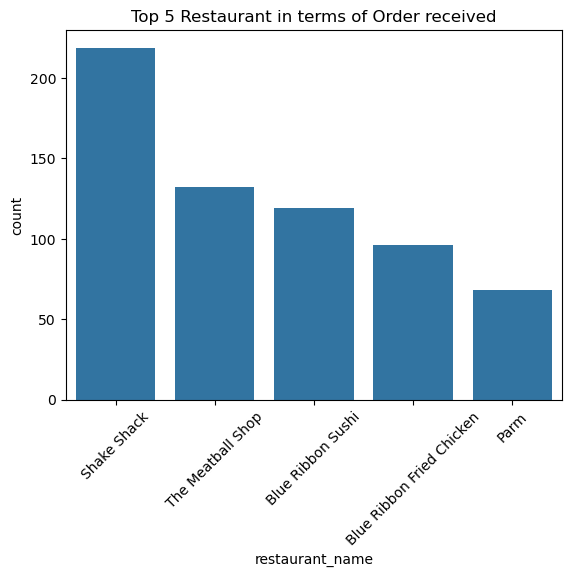

In [151]:
sns.barplot(data=to5_data, x="restaurant_name", y="count")
plt.title("Top 5 Restaurant in terms of Order received")
plt.xticks(rotation=45)
plt.show()

**This is visualization of the the top 5 restaurants in regrards to the orders they received. This indicates that (Shake Shack, The Meatbal Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken and Parm), These restaurants receives more order compared to others, depicting high custormer demand and popularity**

## Analysing to know the most popular cuisines on weekends

In [152]:
count_per_cuisine = df.groupby(['cuisine_type','day_of_the_week'],as_index=False)['order_id'].count()\
        .rename(columns={'order_id':'counts'})\
        .sort_values(by='counts',ascending=False)\
        .reset_index(drop=True)

In [153]:
count_per_cuisine[count_per_cuisine["day_of_the_week"] == "Weekend"]

,cuisine_type,day_of_the_week,counts
0,American,Weekend,415
1,Japanese,Weekend,335
2,Italian,Weekend,207
4,Chinese,Weekend,163
7,Mexican,Weekend,53
9,Indian,Weekend,49
10,Middle Eastern,Weekend,32
11,Mediterranean,Weekend,32
15,Thai,Weekend,15
17,French,Weekend,13


**According to the analysis 415 American, 335 Japanese 207 Italian Cuisines were the most highly cuinsine type on weekend**

# Wanting to find out percentage of orders cost more that 20%

In [154]:
total_cost_of_order = df["cost_of_the_order"].shape[0]

In [155]:
total_cost_of_order

1898

In [156]:
order_cost_above_20d = df[df["cost_of_the_order"] > 20].shape[0]

In [157]:
print("="*80)
print("The percentage of orders cost more than 20$")

print("-"*80)

The percentage of orders cost more than 20$
--------------------------------------------------------------------------------


In [158]:
order_cost_percentage_above20d = (order_cost_above_20d/total_cost_of_order  )*100

In [159]:
print(f"The total percentage of orders cost more than 20 dollers is: {order_cost_percentage_above20d:.2f}%")

The total percentage of orders cost more than 20 dollers is: 29.24%


From the analysis apploximately 30% are orders more than 20%. This is showing us that significant placed orders which are in higher values.

## Exploring to know the mean delivery time

In [160]:
df["delivery_time"].mean()

np.float64(24.161749209694417)

According to the observation the average delivery time is apploximately 24 minutes. This shows the actual time the customers wait for the pickup to the final destination


## We to amalyze the top 3 client who deserve 20% discount by the company

In [161]:
top3_customer_df=df["customer_id"].value_counts().head(3).reset_index()
top3_customer_df

,customer_id,count
0,52832,13
1,47440,10
2,83287,9


In [162]:
top3_customer_df.columns=["customer_id", "number_of_orders"]

In [163]:
top3_customer_df

,customer_id,number_of_orders
0,52832,13
1,47440,10
2,83287,9


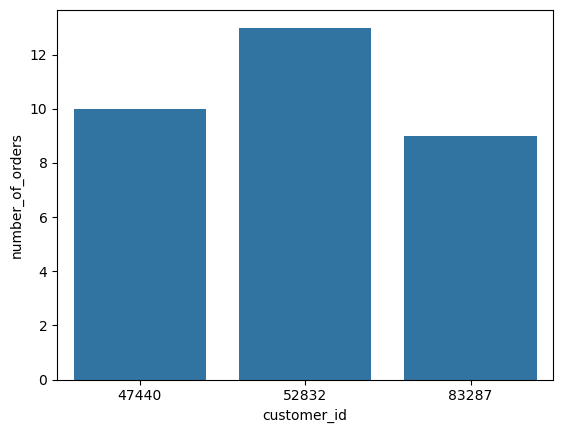

In [164]:
sns.barplot(data =top3_customer_df, x="customer_id", y="number_of_orders" )
plt.show()

This is showing us that [45440, 52832, 83287] IDs were the top three(3) of which id 52832 has the highest number of order 13 followed by id 45440. These three IDs has the eligibility for the 20% discount vochure. Rewarding these royal customers can help imeprove customers rentention and encourage their continues usage of the platform.

# Doing bivariate and multivariate analysis on some signifacant variables

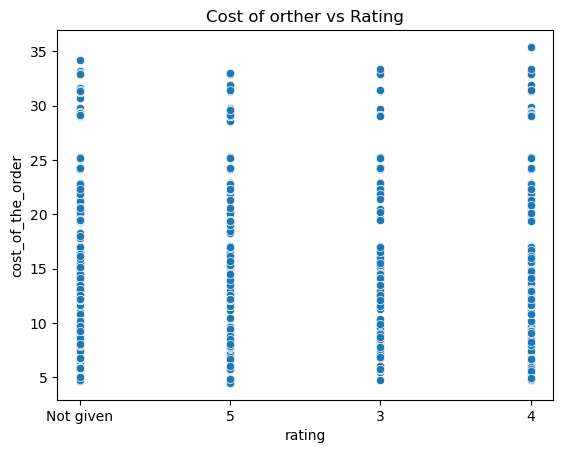

In [165]:
sns.scatterplot(data = df, y="cost_of_the_order", x="rating")
plt.title("Cost of orther vs Rating")
plt.show()

### We want to see if the delivery times reduces customers satisfaction

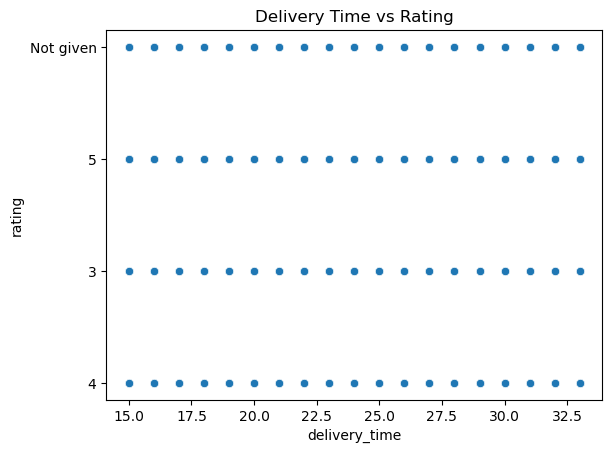

In [166]:
sns.scatterplot(x='delivery_time', y='rating', data=df)
plt.title('Delivery Time vs Rating')
plt.show()

### We are exploring to see which cuisine are more expensive

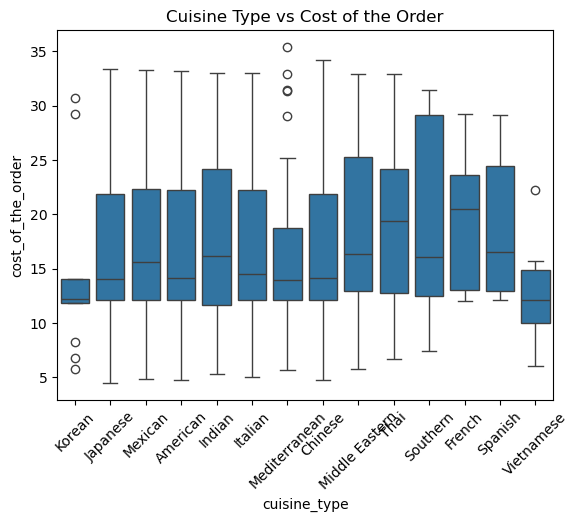

In [167]:
sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=df)
plt.xticks(rotation=45)
plt.title('Cuisine Type vs Cost of the Order')
plt.show()

## Cuisine type  vs Food delivery time

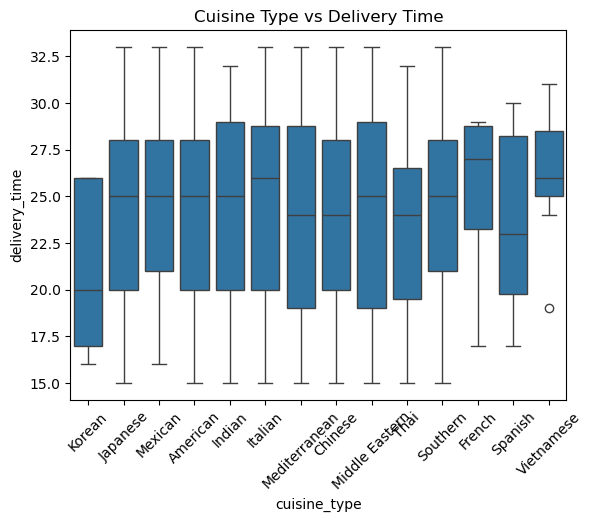

In [168]:
sns.boxplot(x='cuisine_type', y='delivery_time', data=df)
plt.xticks(rotation=45)
plt.title('Cuisine Type vs Delivery Time')
plt.show()

## Checking for demands over the weekdays vs the weekends

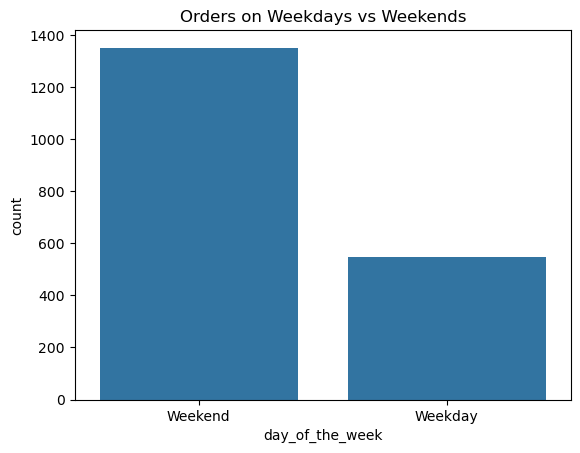

In [169]:
sns.countplot(x='day_of_the_week', data=df)
plt.title('Orders on Weekdays vs Weekends')
plt.show()

## Performing correlation matrix with the numerical variables

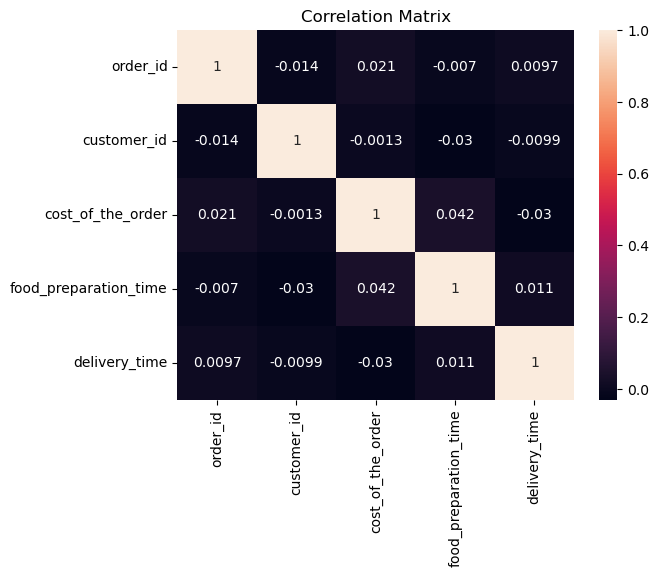

In [6]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

bivariate and multivairiate analysis is conducted to understand the relationship between some key vairables such as Cuisine type, delivery time, cost of order and rating
There is a negative relationship between delivery time and rating, suggesting that longer delivery times reduce customer satisfaction.
Higher-cost orders do not necessarily result in higher ratings.
Certain cuisines tend to have higher average costs than others.
Delivery time varies across cuisine types, indicating operational differences between restaurants.
More orders are placed during weekends compared to weekdays, showing higher demand.
The analysis reveals important relationships between delivery time, cost, cuisine type, and customer ratings. These insights can help the company improve delivery efficiency, pricing strategies, and customer satisfaction

The correlation analysis indicates that there are no strong linear relationships among the key numerical variables in the dataset. This suggests that customer experience and operational performance are influenced by multiple independent factors rather than a single dominant variable

 The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer

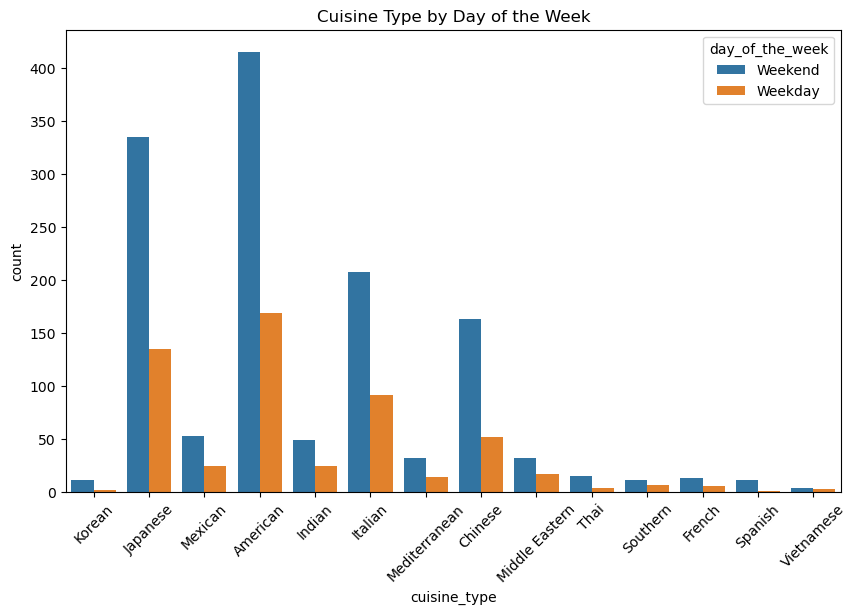

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='cuisine_type', hue='day_of_the_week')
plt.xticks(rotation=45)
plt.title('Cuisine Type by Day of the Week')
plt.show()

The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer.

In [8]:
# We are converting the rating variable to numeric before we can perform some operation like getting the mean
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
## We need to group by restaurant

restaurant_rating = df.groupby("restaurant_name")["rating"].agg(["count","mean"])
# filtering 
qualified_restaurant = restaurant_rating[(restaurant_rating["count"] > 50) & (restaurant_rating["mean"] > 4)]
print(qualified_restaurant)

                           count      mean
restaurant_name                           
Blue Ribbon Fried Chicken     64  4.328125
Blue Ribbon Sushi             73  4.219178
Shake Shack                  133  4.278195
The Meatball Shop             84  4.511905


Our anlysis is indicating that [Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack, The Meatball Shop] were the qualified restaurants fulfiling the criteria

The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders.

In [9]:
# Define a function to calculate revenue based on the rules
def compute_revenue(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0

# Apply the function to the cost column and sum it up
total_revenue = df['cost_of_the_order'].apply(compute_revenue).sum()
print(f"Total Net Revenue Generated by the Company: ${total_revenue:.2f}")

Total Net Revenue Generated by the Company: $6166.30


The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.)

In [11]:
# Create a new column for total time
df['total_time'] = df['food_preparation_time'] + df['delivery_time']
df.head

<bound method NDFrame.head of       order_id  customer_id                        restaurant_name  \
0      1477147       337525                                Hangawi   
1      1477685       358141              Blue Ribbon Sushi Izakaya   
2      1477070        66393                            Cafe Habana   
3      1477334       106968              Blue Ribbon Fried Chicken   
4      1478249        76942                       Dirty Bird to Go   
...        ...          ...                                    ...   
1893   1476701       292602  Chipotle Mexican Grill $1.99 Delivery   
1894   1477421       397537                              The Smile   
1895   1477819        35309                      Blue Ribbon Sushi   
1896   1477513        64151                      Jack's Wife Freda   
1897   1478056       120353                      Blue Ribbon Sushi   

       cuisine_type  cost_of_the_order day_of_the_week  rating  \
0            Korean              30.75         Weekend     NaN 

In [ ]:
# Filter orders where total time exceeds 60 minutes
over_60 = df[df['total_time'] > 60]
over_60.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_time
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3.0,33,30,63
10,1477895,143926,Big Wong Restaurant _¤¾Ñ¼,Chinese,5.92,Weekday,NaN,34,28,62
19,1477354,67487,Blue Ribbon Sushi,Japanese,16.20,Weekend,4.0,35,26,61
24,1476714,363783,Cafe Mogador,Middle Eastern,15.86,Weekday,NaN,32,29,61
54,1477760,130507,Jack's Wife Freda,Mediterranean,22.75,Weekend,3.0,35,29,64


In [13]:
# Calculate the percentage of orders that took more than 60 minutes
total_orders = df.shape[0]
percentage = (over_60.shape[0] / total_orders) * 100
print(f"Percentage of orders over 60 mins: {round(percentage, 2)}%")

Percentage of orders over 60 mins: 10.54%
